In [ ]:
# Projet: Estimation du traffic routier 

In [1]:
# Importation des modules et packages necessaires:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [2]:
# Impotration des données
data = pd.read_csv('D:\\DOCUMENTS\\PROJETS\\Estimation-du-traffic-routier---ATUT2025\\data\\traffic.csv')

# Exploration des données: La base contient le nombre de vehicule à 4 carreours toutes les heures
Notre dataset contient les variables suivantes:
- DateTime: la date de l'observation
- Junction: le numero du carrefour
- Vehicles: Le nombre de vehicules qui ont traversé le carrefour pendant l'heure d'observation

In [3]:
data.head(2)

,DateTime,Junction,Vehicles,ID
0,11/1/2015 0:00,1,15,20151101001
1,11/1/2015 1:00,1,13,20151101011


In [4]:
data.dtypes

DateTime      str
Junction    int64
Vehicles    int64
ID          int64
dtype: object

In [ ]:
# Conversion du type de la variable DateTime en datetime et suppression de la variable ID

In [5]:
data["DateTime"] = pd.to_datetime(data["DateTime"])
data.drop("ID", axis=1, inplace=True)

data.dtypes

DateTime    datetime64[us]
Junction             int64
Vehicles             int64
dtype: object

In [6]:
data.head(2)

,DateTime,Junction,Vehicles
0,2015-11-01 00:00:00,1,15
1,2015-11-01 01:00:00,1,13


In [7]:
data = data.rename(columns={'Junction': 'Jonction', 'Vehicles':'Vehicules', 'DateTime':'DateHeure'})
new_data = data.copy()

In [8]:
# Visualisation des données
def plot_traffic(data):
    plt.figure(figsize=(12, 6))
    sns.lineplot(x= data['DateHeure'], y='Vehicules', data=data, hue='Jonction', palette='colorblind')
    plt.title('Volume du traffic routier au fil du temps')
    plt.xlabel('Date')
    plt.ylabel('Nombre de véhicules')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

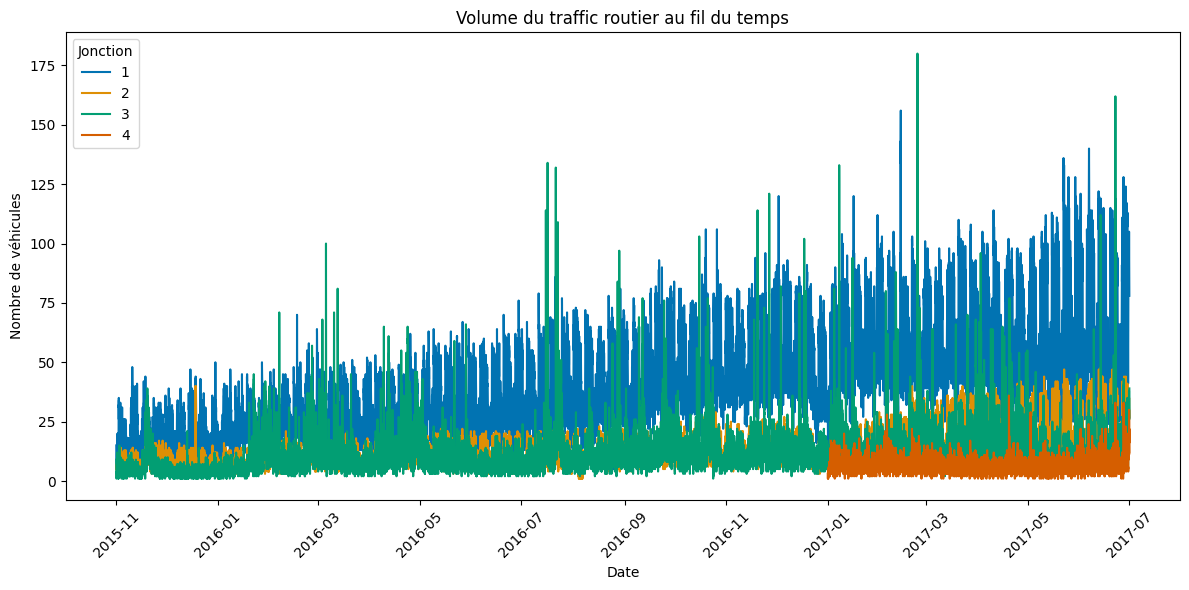

In [9]:
plot_traffic(new_data)

In [10]:
new_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   DateHeure  48120 non-null  datetime64[us]
 1   Jonction   48120 non-null  int64         
 2   Vehicules  48120 non-null  int64         
dtypes: datetime64[us](1), int64(2)
memory usage: 1.1 MB


# Feature engineering: 
Ici je vais construire de nouvelles variables pour extraire des informations surtout à partir de la colonne date.

A partir de la visualisation précédente, on observe que:
- Le nombre de véhicule à la jonction 1 montre une tendence haussière
- Les données sur la jonctions 4, commence seulement à partir de janvier 2017

Donc pour avoir suffisament d'informations, on va devoir extraire les années, les mois, les jours et heures


In [11]:
new_data["Annee"] = pd.to_datetime(new_data["DateHeure"]).dt.year
new_data["Mois"] = pd.to_datetime(new_data["DateHeure"]).dt.month
new_data["Jour"] = pd.to_datetime(new_data["DateHeure"]).dt.day
new_data["Heure"] = pd.to_datetime(new_data["DateHeure"]).dt.hour

new_data.head()

,DateHeure,Jonction,Vehicules,Annee,Mois,Jour,Heure
0,2015-11-01 00:00:00,1,15,2015,11,1,0
1,2015-11-01 01:00:00,1,13,2015,11,1,1
2,2015-11-01 02:00:00,1,10,2015,11,1,2
3,2015-11-01 03:00:00,1,7,2015,11,1,3
4,2015-11-01 04:00:00,1,9,2015,11,1,4


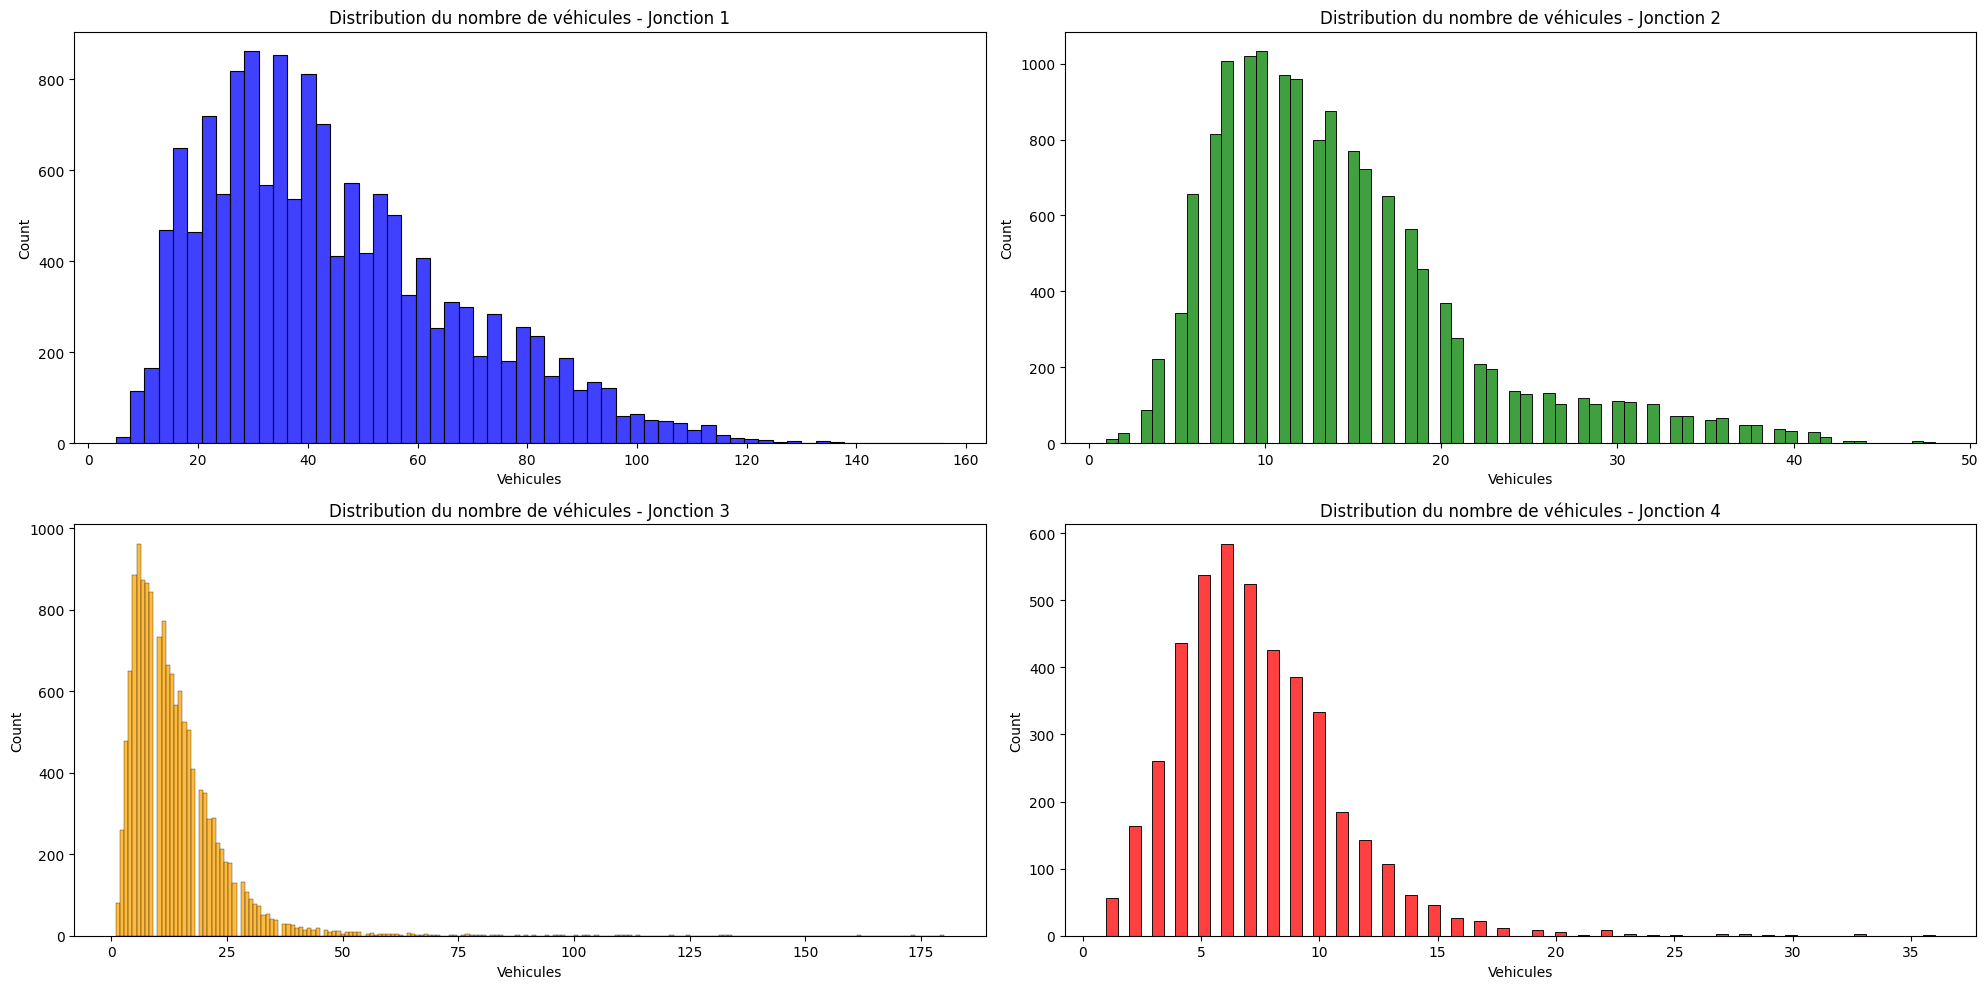

In [12]:
# Verifions la distribution du nombre de vehicules par jonctions
fig, ax = plt.subplots(2, 2, figsize=(20, 10))
ax[0, 0].plot()
sns.histplot( data=new_data[new_data['Jonction'] == 1]["Vehicules"], ax=ax[0, 0], color='blue')
sns.histplot( data=new_data[new_data['Jonction'] == 2]["Vehicules"], ax=ax[0, 1], color='green')
sns.histplot( data=new_data[new_data['Jonction'] == 3]["Vehicules"], ax=ax[1, 0], color='orange')
sns.histplot( data=new_data[new_data['Jonction'] == 4]["Vehicules"], ax=ax[1, 1], color='red')
ax[0, 0].set_title('Distribution du nombre de véhicules - Jonction 1')
ax[0, 1].set_title('Distribution du nombre de véhicules - Jonction 2')
ax[1, 0].set_title('Distribution du nombre de véhicules - Jonction 3')
ax[1, 1].set_title('Distribution du nombre de véhicules - Jonction 4')
plt.tight_layout()  
plt.show()

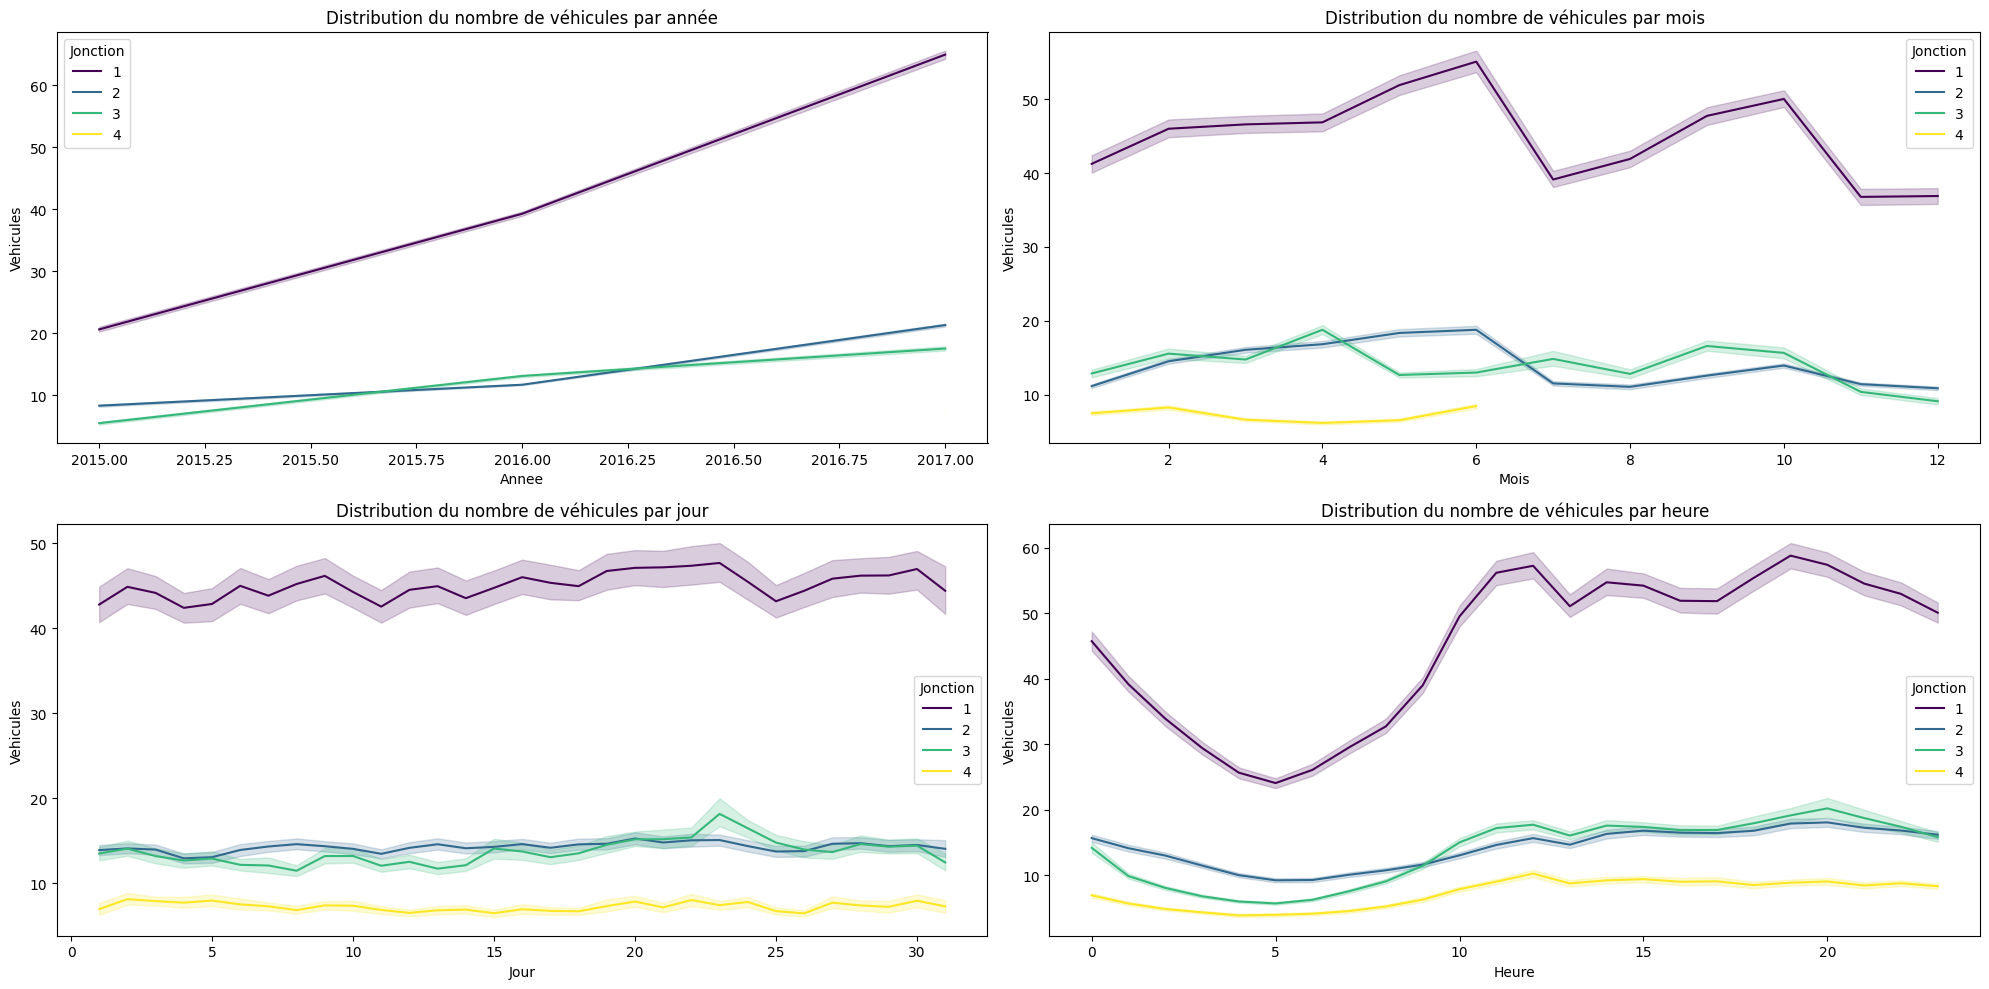

In [13]:
# Examinons l'évolution du nombre de véhicules en fonctions de nos nouvelles variables
fig, ax = plt.subplots(2, 2, figsize=(20, 10))
sns.lineplot(data=new_data, x='Annee', y='Vehicules', ax=ax[0, 0], hue = "Jonction", palette='viridis')
sns.lineplot( data=new_data, x='Mois', y='Vehicules', ax=ax[0, 1], hue = "Jonction", palette='viridis')
sns.lineplot( data=new_data, x='Jour', y='Vehicules', ax=ax[1, 0], hue = "Jonction", palette='viridis')
sns.lineplot( data=new_data, x='Heure', y='Vehicules', ax=ax[1, 1], hue = "Jonction", palette='viridis')
ax[0, 0].set_title('Distribution du nombre de véhicules par année')
ax[0, 1].set_title('Distribution du nombre de véhicules par mois')
ax[1, 0].set_title('Distribution du nombre de véhicules par jour')
ax[1, 1].set_title('Distribution du nombre de véhicules par heure')
plt.tight_layout()  
plt.show()

# On observe sur la figure precedente que:
- Le nombre de véhicule présente une tendence haussière par anné pour toutes les jonctions à l'exception de la jonction 4 pour laquelle nous n'avons les données qu'à partir de 2017
- GLobalement, le nombre de véhicule dans ces jonctions augmente pendant le jour et diminue la nuit

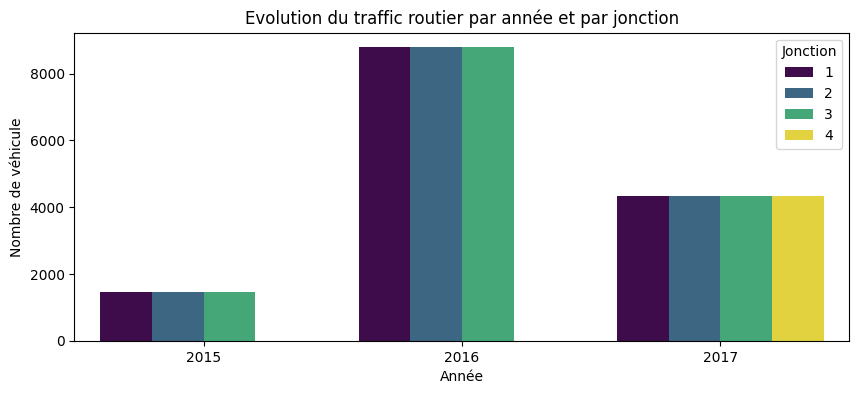

In [14]:
# Analysons l'évolution de ce traffic par année
plt.figure(figsize=(10, 4))
sns.countplot(data = new_data, x = new_data["Annee"], hue = "Jonction", palette="viridis")
plt.title("Evolution du traffic routier par année et par jonction")
plt.xlabel("Année")
plt.ylabel("Nombre de véhicule")
plt.show()

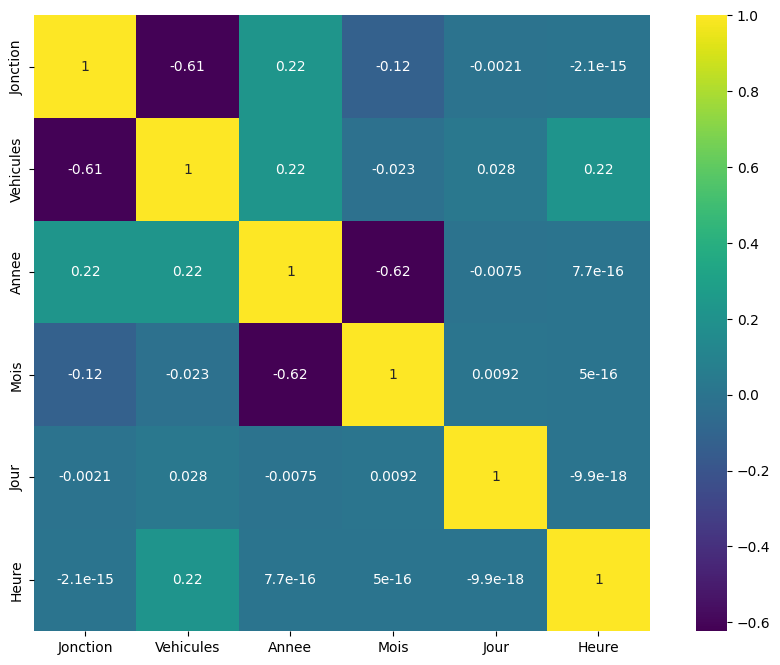

In [15]:
# Augmentation flagrante du traffic sur toutes les jonctions de 2015 à 2016

# Analyse de la correlation entre nos variables

traffic = new_data.copy()

correlations = traffic.drop("DateHeure", axis=1).corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlations, cmap = "viridis", annot=True, square=True)
plt.show()

In [16]:
### Transformations de nos données pour les rendre plus adaptées à l'apprentissage automatique
# parce qu'il va falloire adapter les modeles pour chaque jonction

# Donc nous allons premierement prendre le cas de la premiere jonction pour developper le modele et comme 
# c'est la meme procedure ca ne sea pas complique de le afire pour les autres jonctions

type_jonction = 1

traffic_current = traffic[traffic["Jonction"] == type_jonction]
traffic_current.head(3)

,DateHeure,Jonction,Vehicules,Annee,Mois,Jour,Heure
0,2015-11-01 00:00:00,1,15,2015,11,1,0
1,2015-11-01 01:00:00,1,13,2015,11,1,1
2,2015-11-01 02:00:00,1,10,2015,11,1,2


<Axes: xlabel='Jour', ylabel='Vehicules'>

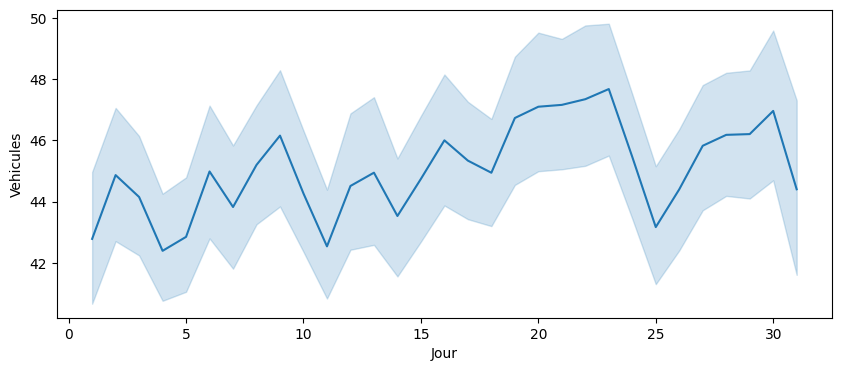

In [17]:
plt.figure(figsize=(10, 4))
sns.lineplot(x="Jour", y="Vehicules", data=traffic_current)

In [ ]:
# Normalisation des donnees avec MinMaxScaler et comme il ya de la saisonnalite on va faire la differenciation
#  Pour la jonction 1, la saisonnalite est d'une semaine, donc on va faire la differenciation avec un lag de 7 jours

In [18]:
def Normalisation(df, col):
    scaler = StandardScaler()
    df[col] = scaler.fit_transform(df[[col]])
    return df, scaler

def Difference(df,col, interval):
    diff = []
    for i in range(interval, len(df)):
        value = df[col][i] - df[col][i - interval]
        diff.append(value)
    return diff

In [19]:
traffic_current, scaler = Normalisation(traffic_current, "Vehicules")
traffic_current.head(2)

,DateHeure,Jonction,Vehicules,Annee,Mois,Jour,Heure
0,2015-11-01 00:00:00,1,-1.306219,2015,11,1,0
1,2015-11-01 01:00:00,1,-1.393147,2015,11,1,1


In [20]:
traffic_norm = traffic_current["Vehicules"].to_frame()

<Figure size 800x400 with 0 Axes>

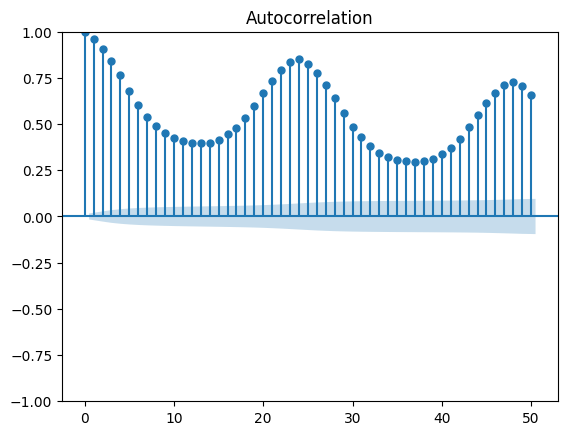

In [21]:
# Analyse des autocorrelations pour determiner les intervalles de differenciation: 
# Seasonalite (Une semaine (7 jours)))

plt.figure(figsize=(8, 4))
plot_acf(traffic_current["Vehicules"],lags=50)
plt.show()

In [22]:
Vehicules_diff = Difference(traffic_current, "Vehicules", interval= (24*7))

interval=24*7

traffic_norm = traffic_norm[interval:]

traffic_norm["Vehicules_diff"] = Vehicules_diff

traffic_traffic = traffic_norm["Vehicules_diff"].dropna()

traffic_traffic = traffic_traffic.to_frame()

traffic_traffic.head(2)

,Vehicules_diff
168,-0.086928
169,0.130392


In [23]:
traffic_traffic.shape

(14424, 1)

In [ ]:
# Etant donnée que nous somme en face des series temporelles, 
# il est important de faire le test de stationnarité des series

In [25]:
def test_stationnarite(df):
    test = adfuller(df.dropna())
    print(f"ADF Statistic: {test[0]}")
    print(f"p-value: {test[1]}")
    print("Critical Values:")
    for key, value in test[4].items():
        print('\t%s: %.3f' % (key, value))
    if test[0] > test[4]["1%"]:
        print("Les series temporelles ne sont pas stationnaires")
    else:
        print("Les series temporelles sont stationnaires") 

test_stationnarite(traffic_traffic["Vehicules_diff"])

ADF Statistic: -15.265303390415374
p-value: 4.798539876397681e-28
Critical Values:
	1%: -3.431
	5%: -2.862
	10%: -2.567
Les series temporelles sont stationnaires


In [ ]:
# Les séries étant désormais stationnaires, nous préparons les données pour la phase de modélisation.

# Nous allons diviser les données en ensembles d'entraînement et de test, 
# en utilisant les 80% premiers points pour l'entraînement et les 20% restants pour le test.

In [26]:
def Split_data(df):
    training_size = int(len(df)*0.8)
    data_len = len(df)
    train, test = df[0:training_size],df[training_size:data_len] 
    train, test = train.values.reshape(-1, 1), test.values.reshape(-1, 1)
    return train, test

# Nous allons maintenant definir les features et les cibles pour l'apprentissage automatique tout en 
# respectant la nature temporelle de nos données donc il va falloire utiliser les retards

def Def_Features_Target(df):
    end_len = len(df)
    X = []
    y = []
    steps = 32
    for i in range(steps, end_len):
        X.append(df[i - steps:i, 0])
        y.append(df[i, 0])
    X, y = np.array(X), np.array(y)
    return X, y

# Regler les problemes de dimensions pour les modeles d'apprentissage automatique
def Correction_dimensions(train, test):
    train = np.reshape(train, (train.shape[0], train.shape[1], 1))
    test = np.reshape(test, (test.shape[0], test.shape[1], 1))
    return train, test

In [27]:
traffic_train, traffic_test = Split_data(traffic_traffic)

X, y = Def_Features_Target(traffic_train)
X_test, y_test = Def_Features_Target(traffic_test)

In [ ]:
########## Comme nous somme en face des sequences, on va utiliser ici 
# LSTM et GRU pour la modelisation de nos données.

In [ ]:
# Modelisation avec LSTM